In [1]:
import os
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
datadir = "/data/users4/xli/MSIVA/MSIVA/results/img"
ss_list = ['s1','s2','s3','s4','s5']
img_loss = np.zeros((2, 3, len(ss_list)))

for i,ss in enumerate(ss_list):
    J_ukb = sio.loadmat(os.path.join(datadir,ss,"J_ukb.mat"))
    img_loss[0,0,i] = np.squeeze(J_ukb["J_um"])
    img_loss[0,1,i] = np.squeeze(J_ukb["J_ummm"])
    img_loss[0,2,i] = np.squeeze(J_ukb["J_mm"])

    J_sz = sio.loadmat(os.path.join(datadir,ss,"J_sz.mat"))
    img_loss[1,0,i] = np.squeeze(J_sz["J_um"])
    img_loss[1,1,i] = np.squeeze(J_sz["J_ummm"])
    img_loss[1,2,i] = np.squeeze(J_sz["J_mm"])

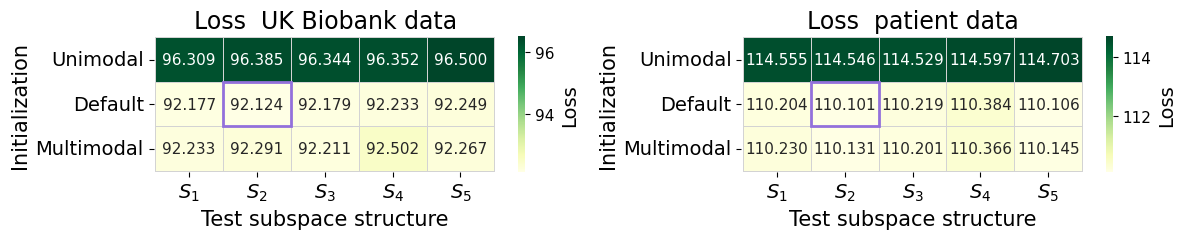

In [3]:
ss_list = ["$S_1$","$S_2$","$S_3$","$S_4$","$S_5$"]
init_list = ["Unimodal","Default","Multimodal"]
title_list=["UK Biobank data","patient data"]
fig, axes = plt.subplots(1, 2, figsize=(6*2, 2.5))
delta = 0.025

for i in range(2):
    ax = axes[i]
    data = img_loss[i,:,:]
    dmax = data.max()
    dmin = data.min()
    heatmap = sns.heatmap(data,vmin=dmin,vmax=dmax,cmap="YlGn",annot=True,fmt=".3f",xticklabels=ss_list,yticklabels=init_list,linewidths=0.5,linecolor='lightgray',ax=ax,annot_kws={"size": 11})#magma_r
    ax.set_title(f"Loss  {title_list[i]}", fontsize=17)
    ax.set_xlabel("Test subspace structure", fontsize=15)
    ax.set_ylabel("Initialization", fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlim(0-delta,5+delta*1.5)
    ax.set_ylim(3+delta*1.5,0-delta)
    min_ind = np.argmin(data[1,:])
    square = plt.Rectangle((min_ind, 1), 1, 1, fill=False, ec="mediumpurple", linewidth=2, zorder=1)
    ax.add_patch(square)
    cbar = heatmap.collections[0].colorbar
    cbar.set_label("Loss", fontsize=14)
    cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(f"figures/neuroimaging_loss.pdf")